In [1]:
import synthpop 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from astroquery.gaia import Gaia

In [3]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia

In [43]:
mod2 = synthpop.SynthPop('huston2025_defaults.synthpop_conf',
                         chosen_bands = ['Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3'],
                         maglim = ['Bessell_I', 22, "remove"],
                         post_processing_kwargs=[{"name": "ProcessDarkCompactObjects","remove": False}],
                         name_for_output='mod2test'
                        )



################################ Settings #################################
 3275756 - # reading default parameters from
 3275758 - default_config_file =  /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 3275764 - # read configuration from 
 3275766 - config_file = '/System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 3275769 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "mod2test",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "random_seed": 769255521,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_l

In [12]:
coord = SkyCoord(ra=280, dec=-60, unit=(u.degree, u.degree), frame='icrs')

width = u.Quantity(0.1, u.deg)

height = u.Quantity(0.1, u.deg)

r = Gaia.query_object_async(coordinate=coord, width=width, height=height)

r.pprint(max_lines=12, max_width=130)

INFO: Query finished. [astroquery.utils.tap.core]
        dist             solution_id     ... epoch_photometry_url
                                         ...                     
-------------------- ------------------- ... --------------------
 0.00260346369939069 1635721458409799680 ...                     
0.003851874134771273 1635721458409799680 ...                     
0.004545426500979364 1635721458409799680 ...                     
                 ...                 ... ...                  ...
 0.02030718597053477 1635721458409799680 ...                     
0.020454730686785445 1635721458409799680 ...                     
0.020802655215775415 1635721458409799680 ...                     
0.021615117161849308 1635721458409799680 ...                     
Length = 50 rows


Launched query: '
                SELECT
                  TOP 50
                  *,
                  DISTANCE(
                    POINT('ICRS', ra, dec),
                    POINT('ICRS', 266.4049962340226, -28.9361724033918)
                  ) AS dist
                FROM
                  gaiadr2.gaia_source
                WHERE
                  1 = CONTAINS(
                    POINT('ICRS', ra, dec),
                    CIRCLE('ICRS', 266.4049962340226, -28.9361724033918, 0.5)
                  )
                ORDER BY
                  dist ASC
                '
------>https
host = gea.esac.esa.int:443
context = /tap-server/tap/async
Content-type = application/x-www-form-urlencoded
303 303
[('Date', 'Wed, 25 Jun 2025 02:15:41 GMT'), ('Server', 'Apache/2.4.6 (SLES Expanded Support platform 7) OpenSSL/1.0.2k-fips mod_jk/1.2.43'), ('Set-Cookie', 'JSESSIONID=0B563724C6CE57B865413FAAC4588797; Path=/tap-server; Secure; HttpOnly'), ('Location', 'https://gea.esac.esa.int/tap-ser

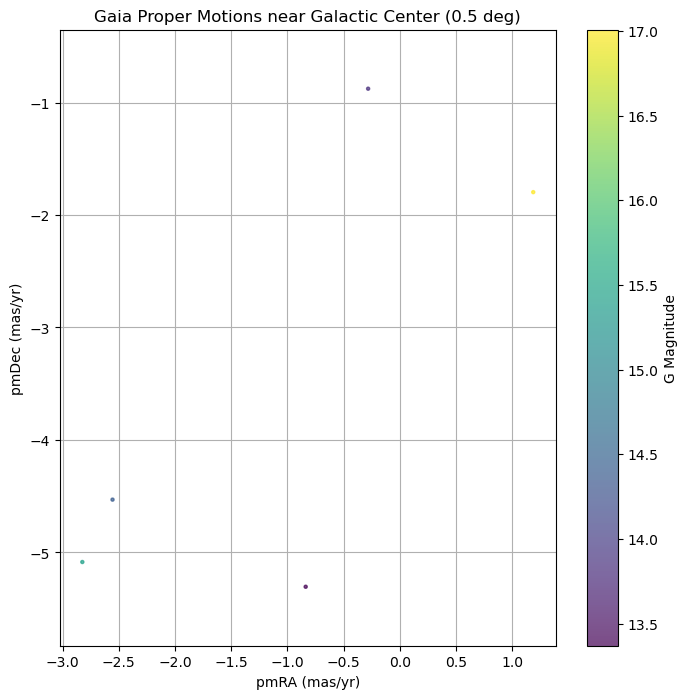

In [18]:
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u

# Define center near Galactic center in ICRS
center = SkyCoord(l=0*u.deg, b=0*u.deg, frame='galactic').icrs

# Search radius
radius = 0.5 * u.deg

# Run cone search with magnitude filter after retrieving results
job = Gaia.cone_search_async(center, radius, verbose=True)
result = job.get_results()

# Filter locally for magnitude and parallax quality
mask = (result['phot_g_mean_mag'] < 19) & (result['parallax_over_error'] > 5)
filtered = result[mask]

print(f"Retrieved {len(filtered)} stars")

# Proceed with plotting filtered stars, e.g. proper motions
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 8))
plt.scatter(filtered['pmra'], filtered['pmdec'],
            c=filtered['phot_g_mean_mag'], cmap='viridis', s=5, alpha=0.7)
plt.xlabel("pmRA (mas/yr)")
plt.ylabel("pmDec (mas/yr)")
plt.title(f"Gaia Proper Motions near Galactic Center ({radius.to(u.deg)})")
plt.colorbar(label="G Magnitude")
plt.grid(True)
plt.axis("equal")
plt.show()


INFO: Query finished. [astroquery.utils.tap.core]
Total stars retrieved: 50
Stars after magnitude filter: 19


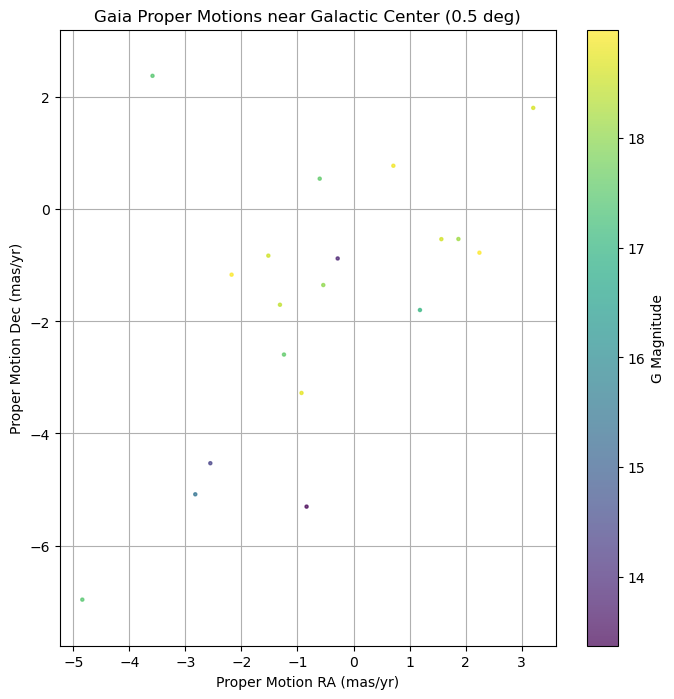

In [21]:
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

# Convert Galactic center (l=0, b=0) to ICRS coordinates
center = SkyCoord(l=0*u.deg, b=0*u.deg, frame='galactic').icrs
radius = 0.5 * u.deg  # search radius

# Perform a cone search with astroquery Gaia
job = Gaia.cone_search_async(center, radius)
result = job.get_results()

print(f"Total stars retrieved: {len(result)}")

# Filter only on magnitude (less than 19)
mask = result['phot_g_mean_mag'] < 19
filtered = result[mask]
print(f"Stars after magnitude filter: {len(filtered)}")

# Remove entries with invalid proper motion values
valid_pm = np.isfinite(filtered['pmra']) & np.isfinite(filtered['pmdec'])
filtered = filtered[valid_pm]

# Plot proper motions
plt.figure(figsize=(8, 8))
scatter = plt.scatter(filtered['pmra'], filtered['pmdec'],
                      c=filtered['phot_g_mean_mag'], cmap='viridis',
                      s=5, alpha=0.7)
plt.xlabel("Proper Motion RA (mas/yr)")
plt.ylabel("Proper Motion Dec (mas/yr)")
plt.title(f"Gaia Proper Motions near Galactic Center ({radius.to(u.deg)})")
plt.colorbar(scatter, label='G Magnitude')
plt.grid(True)
plt.axis('equal')
plt.show()


In [56]:
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

center = SkyCoord(l=-10*u.deg, b=-10*u.deg, frame='galactic').icrs
radius = 1 * u.deg

job = Gaia.cone_search_async(center, radius)
result = job.get_results()

mask = (result['phot_g_mean_mag'] < 30)
filtered = result[mask]

print(f"Stars after filtering: {len(filtered)}")

ra_vals = np.array(filtered['ra'], dtype=float)
dec_vals = np.array(filtered['dec'], dtype=float)
pmra_vals = np.array(filtered['pmra'], dtype=float)
pmdec_vals = np.array(filtered['pmdec'], dtype=float)

coords = SkyCoord(ra=ra_vals*u.deg,
                  dec=dec_vals*u.deg,
                  pm_ra_cosdec=pmra_vals*u.mas/u.yr,
                  pm_dec=pmdec_vals*u.mas/u.yr,
                  frame='icrs')

gal_coords = coords.transform_to('galactic')
pm_l_cosb = gal_coords.pm_l_cosb.to(u.mas/u.yr).value

plt.figure(figsize=(10,6))
plt.hist(pm_l_cosb, bins=50, color='royalblue', alpha=0.75)
plt.xlabel('Proper Motion in Galactic Longitude pm_l* (mas/yr)')
plt.ylabel('Number of Stars')
plt.title('Gaia Proper Motion in Galactic Longitude near Galactic Center (0.5° radius)')
plt.grid(True)
plt.show()


KeyboardInterrupt: 

In [57]:
"""









#Actual work starts here









"""

'\n\n\n\n\n\n\n\n\n\n#Actual work starts here\n\n\n\n\n\n\n\n\n\n'

In [4]:
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

center = SkyCoord(l=-7*u.deg, b=-7*u.deg, frame='galactic').icrs
radius = 0.1 * u.deg

Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"
Gaia.ROW_LIMIT=-1
job = Gaia.cone_search_async(center, radius)
result = job.get_results()

print(result)

mask = (result['phot_g_mean_mag'] < 20)
filtered = result[mask]

print(f"Stars after filtering: {len(filtered)}")

ra_vals = np.array(filtered['ra'], dtype=float)
dec_vals = np.array(filtered['dec'], dtype=float)
pmra_vals = np.array(filtered['pmra'], dtype=float)
pmdec_vals = np.array(filtered['pmdec'], dtype=float)

coords = SkyCoord(ra=ra_vals*u.deg,
                  dec=dec_vals*u.deg,
                  pm_ra_cosdec=pmra_vals*u.mas/u.yr,
                  pm_dec=pmdec_vals*u.mas/u.yr,
                  frame='icrs')

gal_coords = coords.transform_to('galactic')
pm_l_cosb = gal_coords.pm_l_cosb.to(u.mas/u.yr).value

plt.figure(figsize=(10,6))
plt.hist(pm_l_cosb, bins=50, color='royalblue', alpha=0.75)
plt.xlabel('Proper Motion in Galactic Longitude pm_l* (mas/yr)')
plt.ylabel('Number of Stars')
plt.title('Gaia Proper Motion in Galactic Longitude near Galactic Center (0.01° radius)')
plt.grid(True)
plt.show()

INFO: Query finished. [astroquery.utils.tap.core]
    solution_id             DESIGNATION               SOURCE_ID      ... libname_gspphot          dist        
                                                                     ...                                      
------------------- ---------------------------- ------------------- ... --------------- ---------------------
1636148068921376768 Gaia DR3 4036600484660268800 4036600484660268800 ...                 0.0006951639483051754
1636148068921376768 Gaia DR3 4036600480323035136 4036600480323035136 ...           MARCS 0.0010982016271534935
1636148068921376768 Gaia DR3 4036600484697283584 4036600484697283584 ...                    0.0012488283939548
1636148068921376768 Gaia DR3 4036600484697285888 4036600484697285888 ...                 0.0012645022105622714
1636148068921376768 Gaia DR3 4036600484676261504 4036600484676261504 ...                 0.0013434793380044086
1636148068921376768 Gaia DR3 4036600484683814528 4036600484683

AttributeError: 'SkyCoord' object has no attribute 'pm_b_cosb'

In [5]:
"""
mask = (result['phot_g_mean_mag'] < 21)
filtered = result[mask]

print(f"Stars after filtering: {len(filtered)}")

ra_vals = np.array(filtered['ra'], dtype=float)
dec_vals = np.array(filtered['dec'], dtype=float)
pmra_vals = np.array(filtered['pmra'], dtype=float)
pmdec_vals = np.array(filtered['pmdec'], dtype=float)

coords = SkyCoord(ra=ra_vals*u.deg,
                  dec=dec_vals*u.deg,
                  pm_ra_cosdec=pmra_vals*u.mas/u.yr,
                  pm_dec=pmdec_vals*u.mas/u.yr,
                  frame='icrs')

gal_coords = coords.transform_to('galactic')
pm_l_cosb = gal_coords.pm_l_cosb.to(u.mas/u.yr).value

plt.figure(figsize=(10,6))
plt.hist(pm_l_cosb, bins=50, color='royalblue', alpha=0.75)
plt.xlabel('Proper Motion in Galactic Longitude pm_l* (mas/yr)')
plt.ylabel('Number of Stars')
plt.title('Gaia Proper Motion in Galactic Longitude near Galactic Center (0.01° radius)')
plt.grid(True)
plt.show()
"""

'\nmask = (result[\'phot_g_mean_mag\'] < 21)\nfiltered = result[mask]\n\nprint(f"Stars after filtering: {len(filtered)}")\n\nra_vals = np.array(filtered[\'ra\'], dtype=float)\ndec_vals = np.array(filtered[\'dec\'], dtype=float)\npmra_vals = np.array(filtered[\'pmra\'], dtype=float)\npmdec_vals = np.array(filtered[\'pmdec\'], dtype=float)\n\ncoords = SkyCoord(ra=ra_vals*u.deg,\n                  dec=dec_vals*u.deg,\n                  pm_ra_cosdec=pmra_vals*u.mas/u.yr,\n                  pm_dec=pmdec_vals*u.mas/u.yr,\n                  frame=\'icrs\')\n\ngal_coords = coords.transform_to(\'galactic\')\npm_l_cosb = gal_coords.pm_l_cosb.to(u.mas/u.yr).value\n\nplt.figure(figsize=(10,6))\nplt.hist(pm_l_cosb, bins=50, color=\'royalblue\', alpha=0.75)\nplt.xlabel(\'Proper Motion in Galactic Longitude pm_l* (mas/yr)\')\nplt.ylabel(\'Number of Stars\')\nplt.title(\'Gaia Proper Motion in Galactic Longitude near Galactic Center (0.01° radius)\')\nplt.grid(True)\nplt.show()\n'

In [6]:
synthdata = synthpop.SynthPop('huston2025_defaults.synthpop_conf',
                         chosen_bands = ['Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3'],
                         maglim = ['Gaia_G_EDR3', 20, "remove"],
                         post_processing_kwargs=[{"name": "ProcessDarkCompactObjects","remove": True}],
                         name_for_output='mod2test'
                        )

### GAIA Data is in G band
### , 'Gaia_BP_EDR3', 'Gaia_RP_EDR3'

 72091 - Execution Date: 31-07-2025 18:13:59


################################ Settings #################################
 72098 - # reading default parameters from
 72100 - default_config_file =  /System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/config_files/_default.synthpop_conf 
 72107 - # read configuration from 
 72109 - config_file = '/System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
 72112 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "mod2test",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "random_seed": 1674503469,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22

In [7]:
synthdata.init_populations()



########################## initialize population ##########################
 72137 - read Population files from Huston2025


# Population 0;  bulge ----------------------------------------------------
 72156 - # Initialize Population 0 (bulge) from 
 72158 - pop_file = '/System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/models/Huston2025/bulge.popjson'


# Population 1;  halo -----------------------------------------------------
 137820 - # Initialize Population 1 (halo) from 
 137822 - pop_file = '/System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/models/Huston2025/halo.popjson'


# Population 2;  nsd ------------------------------------------------------
 139204 - # Initialize Population 2 (nsd) from 
 139206 - pop_file = '/System/Volumes/Data/mnt/g3/scratch/rileypatlak/code/synthpop/synthpop/models/Huston2025/nsd.popjson'


# Population 3;  thick_disk -----------------------------------------------
 141457 - # Initialize Population 3 (thick_

In [8]:
cat2, distr2 = synthdata.process_location(l_deg=-7, b_deg=-7, solid_angle=.01*(np.pi), solid_angle_unit='deg^2')



############################# update location #############################
 153604 - # set location to: 
 153611 - l, b = (-7.00 deg, -7.00 deg)
 153663 - # set solid_angle to:
 153666 - solid_angle = 3.142e-02 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 165177 - # From density profile (number density)
 165181 - expected_total_iMass = 520343.9153
 165184 - expected_total_eMass = 285220.5543
 165187 - average_iMass_per_star = 0.5739
 165190 - mass_loss_correction = 0.5481
 165193 - n_expected_stars = 906734.2513
 165199 - # Determine velocities when position are generated 


  0%|          | 0/906688 [00:00<?, ?it/s]

 181126 - # From Generated Field:
 181128 - generated_stars = 14379
 181133 - generated_total_iMass = 13975.4712
 181144 - generated_total_eMass = 13950.6710
 181149 - det_mass_loss_corr = 0.9982
 181231 - # Done


# Population 1;  halo -----------------------------------------------------
 181848 - # From density profile (number density)
 181852 - expected_total_iMass = 2468.6711
 181856 - expected_total_eMass = 1299.5737
 181860 - average_iMass_per_star = 0.5739
 181863 - mass_loss_correction = 0.5264
 181867 - n_expected_stars = 4301.8254
 181874 - # Determine velocities when position are generated 
 182059 - # From Generated Field:
 182062 - generated_stars = 62
 182066 - generated_total_iMass = 44.6548
 182077 - generated_total_eMass = 44.5839
 182081 - det_mass_loss_corr = 0.9984
 182151 - # Done


# Population 2;  nsd ------------------------------------------------------
 183615 - # From density profile (number density)
 183620 - expected_total_iMass = 0.0000
 183623 - expected

In [9]:
cat2

,pop,iMass,age,Fe/H_initial,Mass,In_Final_Phase,Dist,l,b,vr_bc,...,A_Ks,logL,logTeff,logg,Fe/H_evolved,log_radius,phase,Gaia_G_EDR3,Gaia_BP_EDR3,Gaia_RP_EDR3
0,0.0,1.052548,10.000000,0.216003,1.051988,0.0,3.823990,353.029960,-7.076076,167.353821,...,0.056439,0.342647,3.740121,4.032556,0.199396,0.213759,2.0,17.426007,18.056784,16.721306
1,0.0,0.870835,10.000000,0.144251,0.870668,0.0,3.952586,352.976950,-7.057552,92.221308,...,0.041867,-0.260907,3.720176,4.473477,0.117757,-0.048129,0.0,18.862456,19.466712,18.162262
2,0.0,0.838007,10.000000,0.087713,0.837865,0.0,4.067394,352.957725,-6.987881,122.868520,...,0.028905,-0.337981,3.712507,4.502084,0.057898,-0.071328,0.0,18.970821,19.529078,18.295414
3,0.0,0.766173,10.000000,-0.108524,0.766061,0.0,4.232650,352.955598,-7.013681,169.992073,...,0.027691,-0.461266,3.704232,4.552604,-0.150842,-0.116420,0.0,19.377234,19.943333,18.691610
4,0.0,0.983140,10.000000,0.460493,0.982892,0.0,4.236729,352.909127,-6.997449,170.882401,...,0.036501,-0.066008,3.727773,4.362234,0.462439,0.034128,0.0,18.426821,19.000916,17.749923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18785,10.0,0.994022,7.043937,-0.433769,0.993510,0.0,9.520139,352.980205,-7.093943,-114.834486,...,0.049395,0.510300,3.795804,4.062813,-0.648078,0.186220,0.0,18.925401,19.398673,18.375441
18786,10.0,0.973557,7.960873,-0.509594,0.972834,0.0,9.785274,352.934762,-7.065490,-53.847693,...,0.037996,0.595209,3.743921,3.761254,-0.525108,0.332440,2.0,18.637121,19.151855,18.013873
18787,10.0,0.923332,8.357909,-0.374903,0.922947,0.0,10.215510,353.092004,-7.013256,-30.306522,...,0.046862,0.259357,3.785595,4.240936,-0.510701,0.081167,0.0,19.665010,20.146422,19.099133
18788,10.0,0.961840,8.817012,-0.460660,0.961159,0.0,12.894155,352.966388,-7.083992,7.730050,...,0.056572,0.719708,3.707492,3.485704,-0.447315,0.467546,2.0,19.209357,19.892019,18.449632


In [10]:
print(list(cat2.columns))

['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist', 'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR', 'A_Ks', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius', 'phase', 'Gaia_G_EDR3', 'Gaia_BP_EDR3', 'Gaia_RP_EDR3']


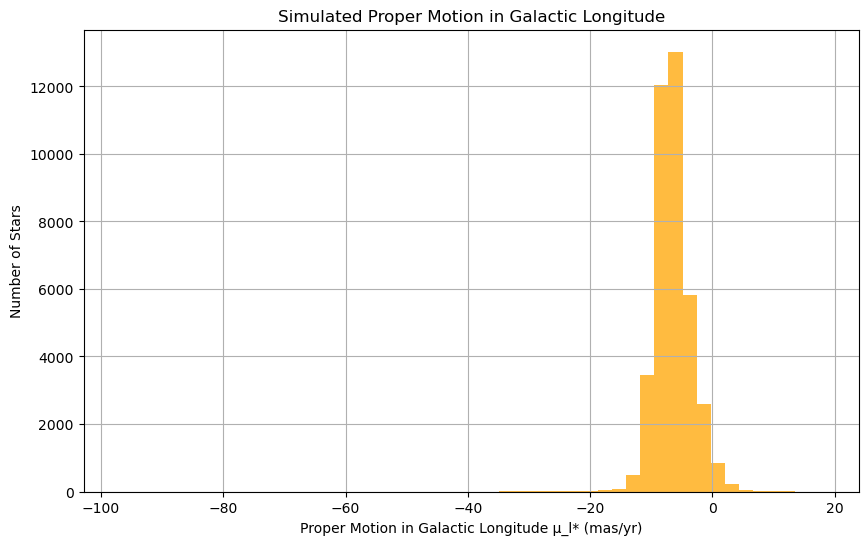

In [22]:
import matplotlib.pyplot as plt

mul_vals = cat2['mul'].astype(float).values

plt.figure(figsize=(10,6))
plt.hist(mul_vals, bins=50, color='orange', alpha=0.75)
plt.xlabel('Proper Motion in Galactic Longitude μ_l* (mas/yr)')
plt.ylabel('Number of Stars')
plt.title('Simulated Proper Motion in Galactic Longitude')
plt.grid(True)
plt.show()


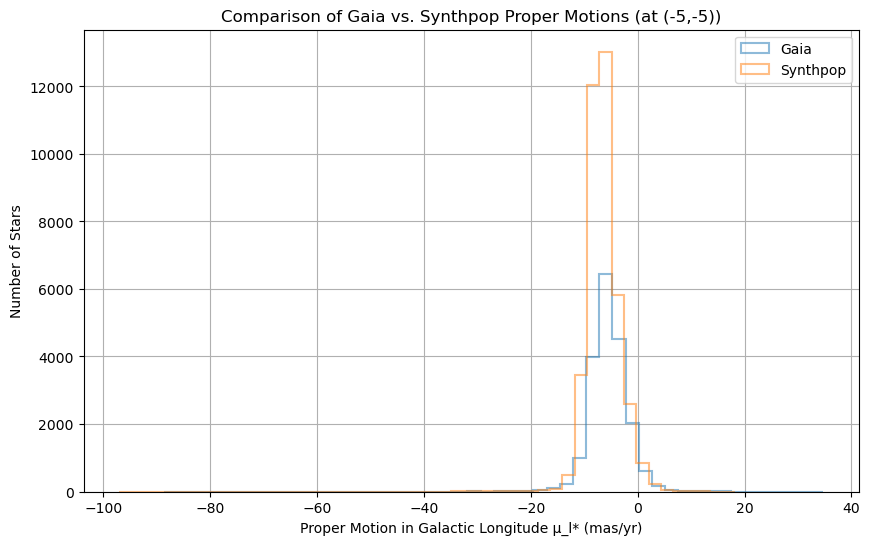

In [29]:
mul_vals = cat2['mul'].astype(float).values

plt.figure(figsize=(10,6))
plt.hist(pm_l_cosb, bins=50, histtype='step', color='C0', linewidth=1.5, alpha=0.5, label='Gaia')
plt.hist(mul_vals, bins=50, histtype='step', color='C1', linewidth=1.5, alpha=0.5, label='Synthpop')
plt.xlabel('Proper Motion in Galactic Longitude μ_l* (mas/yr)')
plt.ylabel('Number of Stars')
plt.title('Comparison of Gaia vs. Synthpop Proper Motions (at (-5,-5))')
plt.legend()
plt.grid(True)
plt.show()


In [39]:
print(np.min(mul_vals))
print(np.max(mul_vals))

-97.07310117834014
18.17839628994476


In [40]:
### Created a -120 for some reason μ_l* 

In [41]:
##### Make B band histogram
##### more sightlines 

In [42]:
### Find mean and median of both queries
### Every degree 

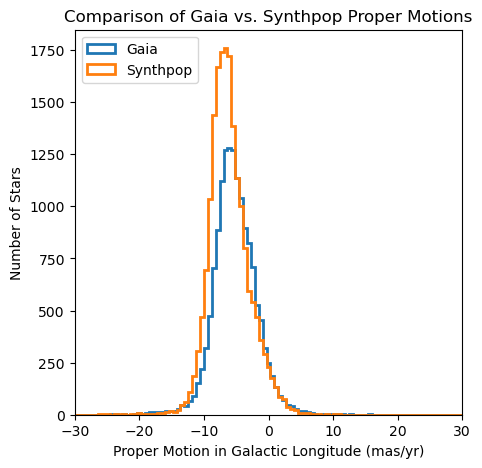

In [11]:
mul_vals = cat2['mul'].astype(float).values
bin_edges = np.linspace(-30, 30, 100)

plt.figure(figsize=(5,5))
plt.hist(pm_l_cosb, bins=bin_edges, histtype='step', color='#1f77b4', linewidth=2, label='Gaia')
plt.hist(mul_vals, bins=bin_edges, histtype='step', color='#ff7f0e', linewidth=2, label='Synthpop')
plt.xlabel('Proper Motion in Galactic Longitude (mas/yr)')
plt.ylabel('Number of Stars')
plt.title('Comparison of Gaia vs. Synthpop Proper Motions')
plt.legend()
plt.xlim(-30, 30)
plt.legend(loc='upper left', frameon=True)
plt.show()

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.07963096e-04, 1.07963096e-04, 0.00000000e+00, 1.61944644e-04,
        0.00000000e+00, 1.07963096e-04, 1.61944644e-04, 1.07963096e-04,
        5.39815481e-05, 1.07963096e-04, 1.07963096e-04, 5.39815481e-05,
        5.39815481e-05, 5.39815481e-05, 1.61944644e-04, 3.23889289e-04,
        0.00000000e+00, 1.61944644e-04, 2.69907741e-04, 1.61944644e-04,
        3.77870837e-04, 9.17686318e-04, 1.78139109e-03, 2.69907741e-03,
        3.67074527e-03, 7.50343519e-03, 1.27936269e-02, 2.20784532e-02,
        3.44402277e-02, 5.60328470e-02, 7.65998168e-02, 1.02726886e-01,
        1.35115815e-01, 1.54387228e-01, 1.60757050e-01, 1.61890663e-01,
        1.46074069e-01, 1.22322188e-01, 1.02079108e-01, 8.30236210e-02,
        7.00140679e-02, 5.22541386e-02, 4.26994046e-02, 2.92040175e-02,
        2.14846562e-02, 1.52227966e-02, 1.15520513e-02, 5.88398875e-03,
        4.69639469e-03, 2.96898515e-03, 1.51148335e-03, 9.176863

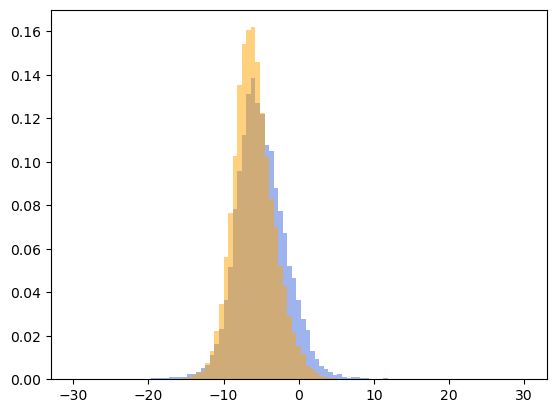

In [40]:
plt.hist(pm_l_cosb, bins=bin_edges, alpha=0.5, label='Gaia', color='royalblue', density=True)
plt.hist(mul_vals, bins=bin_edges, alpha=0.5, label='Synthpop', color='orange', density=True)


INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]


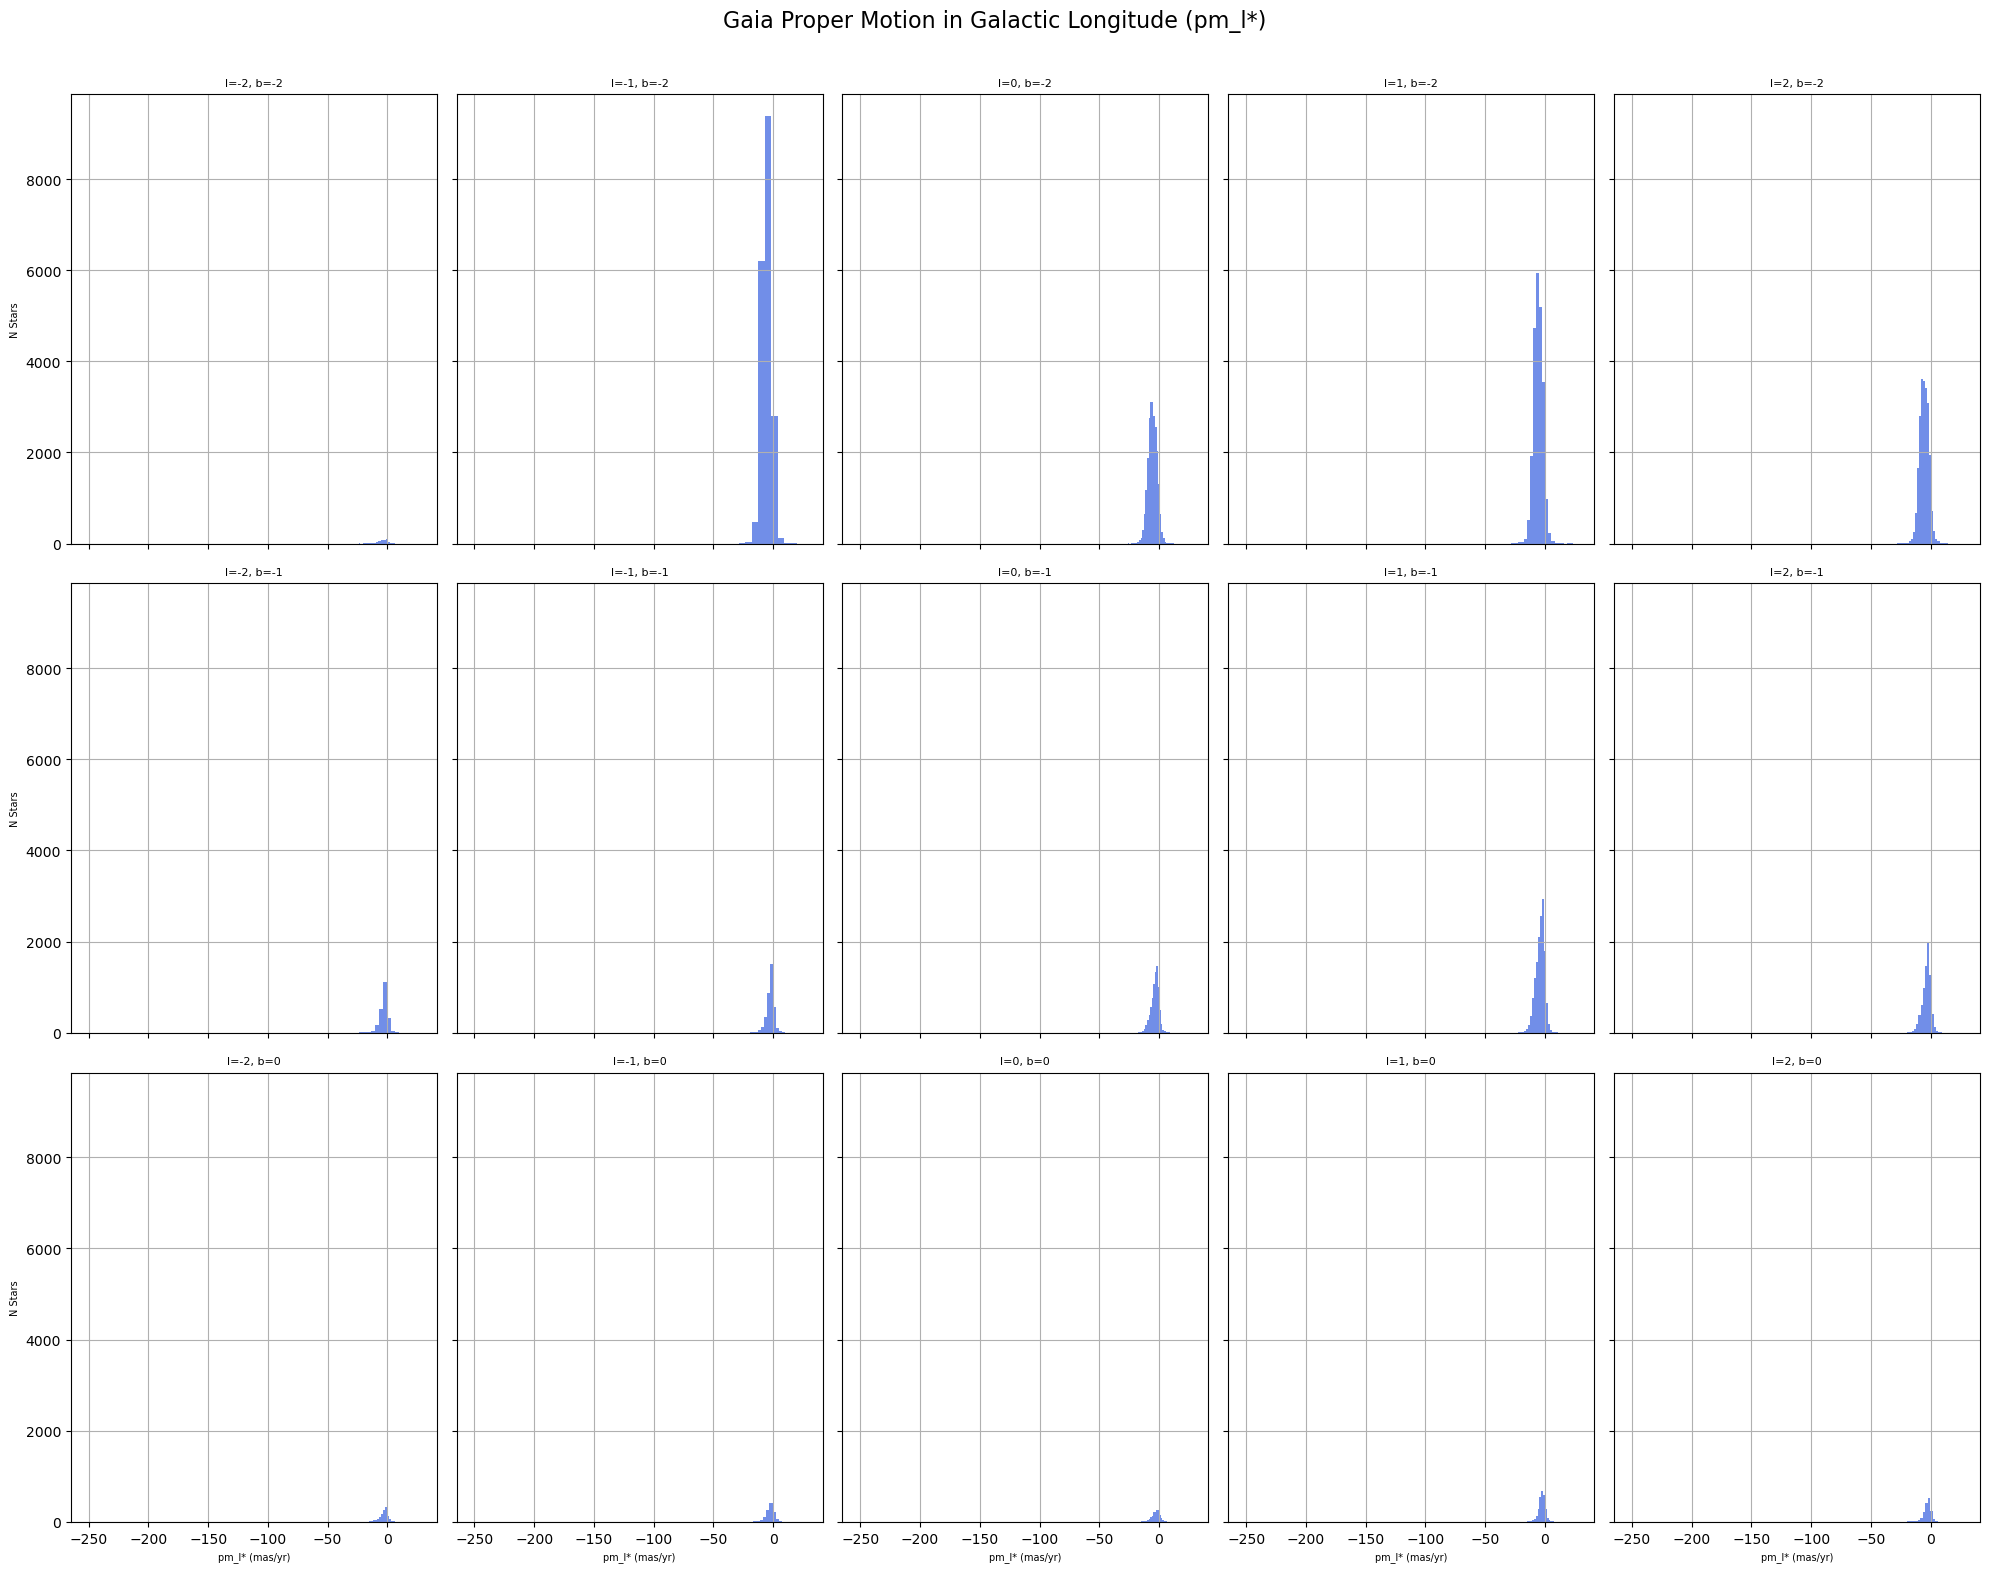

In [44]:
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"
Gaia.ROW_LIMIT = -1

l_vals = np.arange(-2, 3, 1)
b_vals = np.arange(-2, 1, 1)

fig, axes = plt.subplots(len(b_vals), len(l_vals), figsize=(20, 16), sharex=True, sharey=True)
fig.suptitle("Gaia Proper Motion in Galactic Longitude (pm_l*)", fontsize=16)

for i, b in enumerate(b_vals):
    for j, l in enumerate(l_vals):
        center = SkyCoord(l=l*u.deg, b=b*u.deg, frame='galactic').icrs
        radius = 0.1 * u.deg

        try:
            job = Gaia.cone_search_async(center, radius)
            result = job.get_results()

            mask = (result['phot_g_mean_mag'] < 20)
            filtered = result[mask]

            ra_vals = np.array(filtered['ra'], dtype=float)
            dec_vals = np.array(filtered['dec'], dtype=float)
            pmra_vals = np.array(filtered['pmra'], dtype=float)
            pmdec_vals = np.array(filtered['pmdec'], dtype=float)

            coords = SkyCoord(ra=ra_vals*u.deg,
                              dec=dec_vals*u.deg,
                              pm_ra_cosdec=pmra_vals*u.mas/u.yr,
                              pm_dec=pmdec_vals*u.mas/u.yr,
                              frame='icrs')

            gal_coords = coords.transform_to('galactic')
            pm_l_cosb = gal_coords.pm_l_cosb.to(u.mas/u.yr).value

            ax = axes[i, j]
            ax.hist(pm_l_cosb, bins=50, color='royalblue', alpha=0.75)
            ax.set_title(f"l={l}, b={b}", fontsize=8)
            ax.grid(True)

            if i == len(b_vals) - 1:
                ax.set_xlabel('pm_l* (mas/yr)', fontsize=7)
            if j == 0:
                ax.set_ylabel('N Stars', fontsize=7)

        except Exception as e:
            axes[i, j].text(0.5, 0.5, 'Error', ha='center', va='center')
            axes[i, j].set_title(f"l={l}, b={b}", fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()




############################# update location #############################
 1266874 - # set location to: 
 1266877 - l, b = (-9.00 deg, -9.00 deg)
 1266881 - # set solid_angle to:
 1266884 - solid_angle = 3.142e-02 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 1269921 - # From density profile (number density)
 1269925 - expected_total_iMass = 146265.4062
 1269928 - expected_total_eMass = 80173.7063
 1269931 - average_iMass_per_star = 0.5739
 1269934 - mass_loss_correction = 0.5481
 1269937 - n_expected_stars = 254877.3026
 1269943 - # Determine velocities when position are generated 


  0%|          | 0/254574 [00:00<?, ?it/s]

 1274830 - # From Generated Field:
 1274833 - generated_stars = 5011
 1274836 - generated_total_iMass = 4813.2044
 1274849 - generated_total_eMass = 4805.0292
 1274853 - det_mass_loss_corr = 0.9983
 1274924 - # Done


# Population 1;  halo -----------------------------------------------------
 1275622 - # From density profile (number density)
 1275627 - expected_total_iMass = 1742.2026
 1275631 - expected_total_eMass = 917.1415
 1275634 - average_iMass_per_star = 0.5739
 1275637 - mass_loss_correction = 0.5264
 1275641 - n_expected_stars = 3035.9052
 1275648 - # Determine velocities when position are generated 
 1275820 - # From Generated Field:
 1275824 - generated_stars = 35
 1275827 - generated_total_iMass = 25.6913
 1275837 - generated_total_eMass = 25.6761
 1275842 - det_mass_loss_corr = 0.9994
 1275911 - # Done


# Population 2;  nsd ------------------------------------------------------
 1277464 - # From density profile (number density)
 1277469 - expected_total_iMass = 0.0000
 

  0%|          | 0/298981 [00:00<?, ?it/s]

 1298752 - # From Generated Field:
 1298756 - generated_stars = 8052
 1298759 - generated_total_iMass = 7550.5787
 1298770 - generated_total_eMass = 7541.5585
 1298774 - det_mass_loss_corr = 0.9988
 1298837 - # Done


# Population 1;  halo -----------------------------------------------------
 1299523 - # From density profile (number density)
 1299527 - expected_total_iMass = 1839.2928
 1299531 - expected_total_eMass = 968.2524
 1299535 - average_iMass_per_star = 0.5739
 1299539 - mass_loss_correction = 0.5264
 1299542 - n_expected_stars = 3205.0913
 1299550 - # Determine velocities when position are generated 
 1299735 - # From Generated Field:
 1299739 - generated_stars = 48
 1299742 - generated_total_iMass = 33.7441
 1299753 - generated_total_eMass = 33.6903
 1299757 - det_mass_loss_corr = 0.9984
 1299824 - # Done


# Population 2;  nsd ------------------------------------------------------
 1301455 - # From density profile (number density)
 1301460 - expected_total_iMass = 0.0000
 

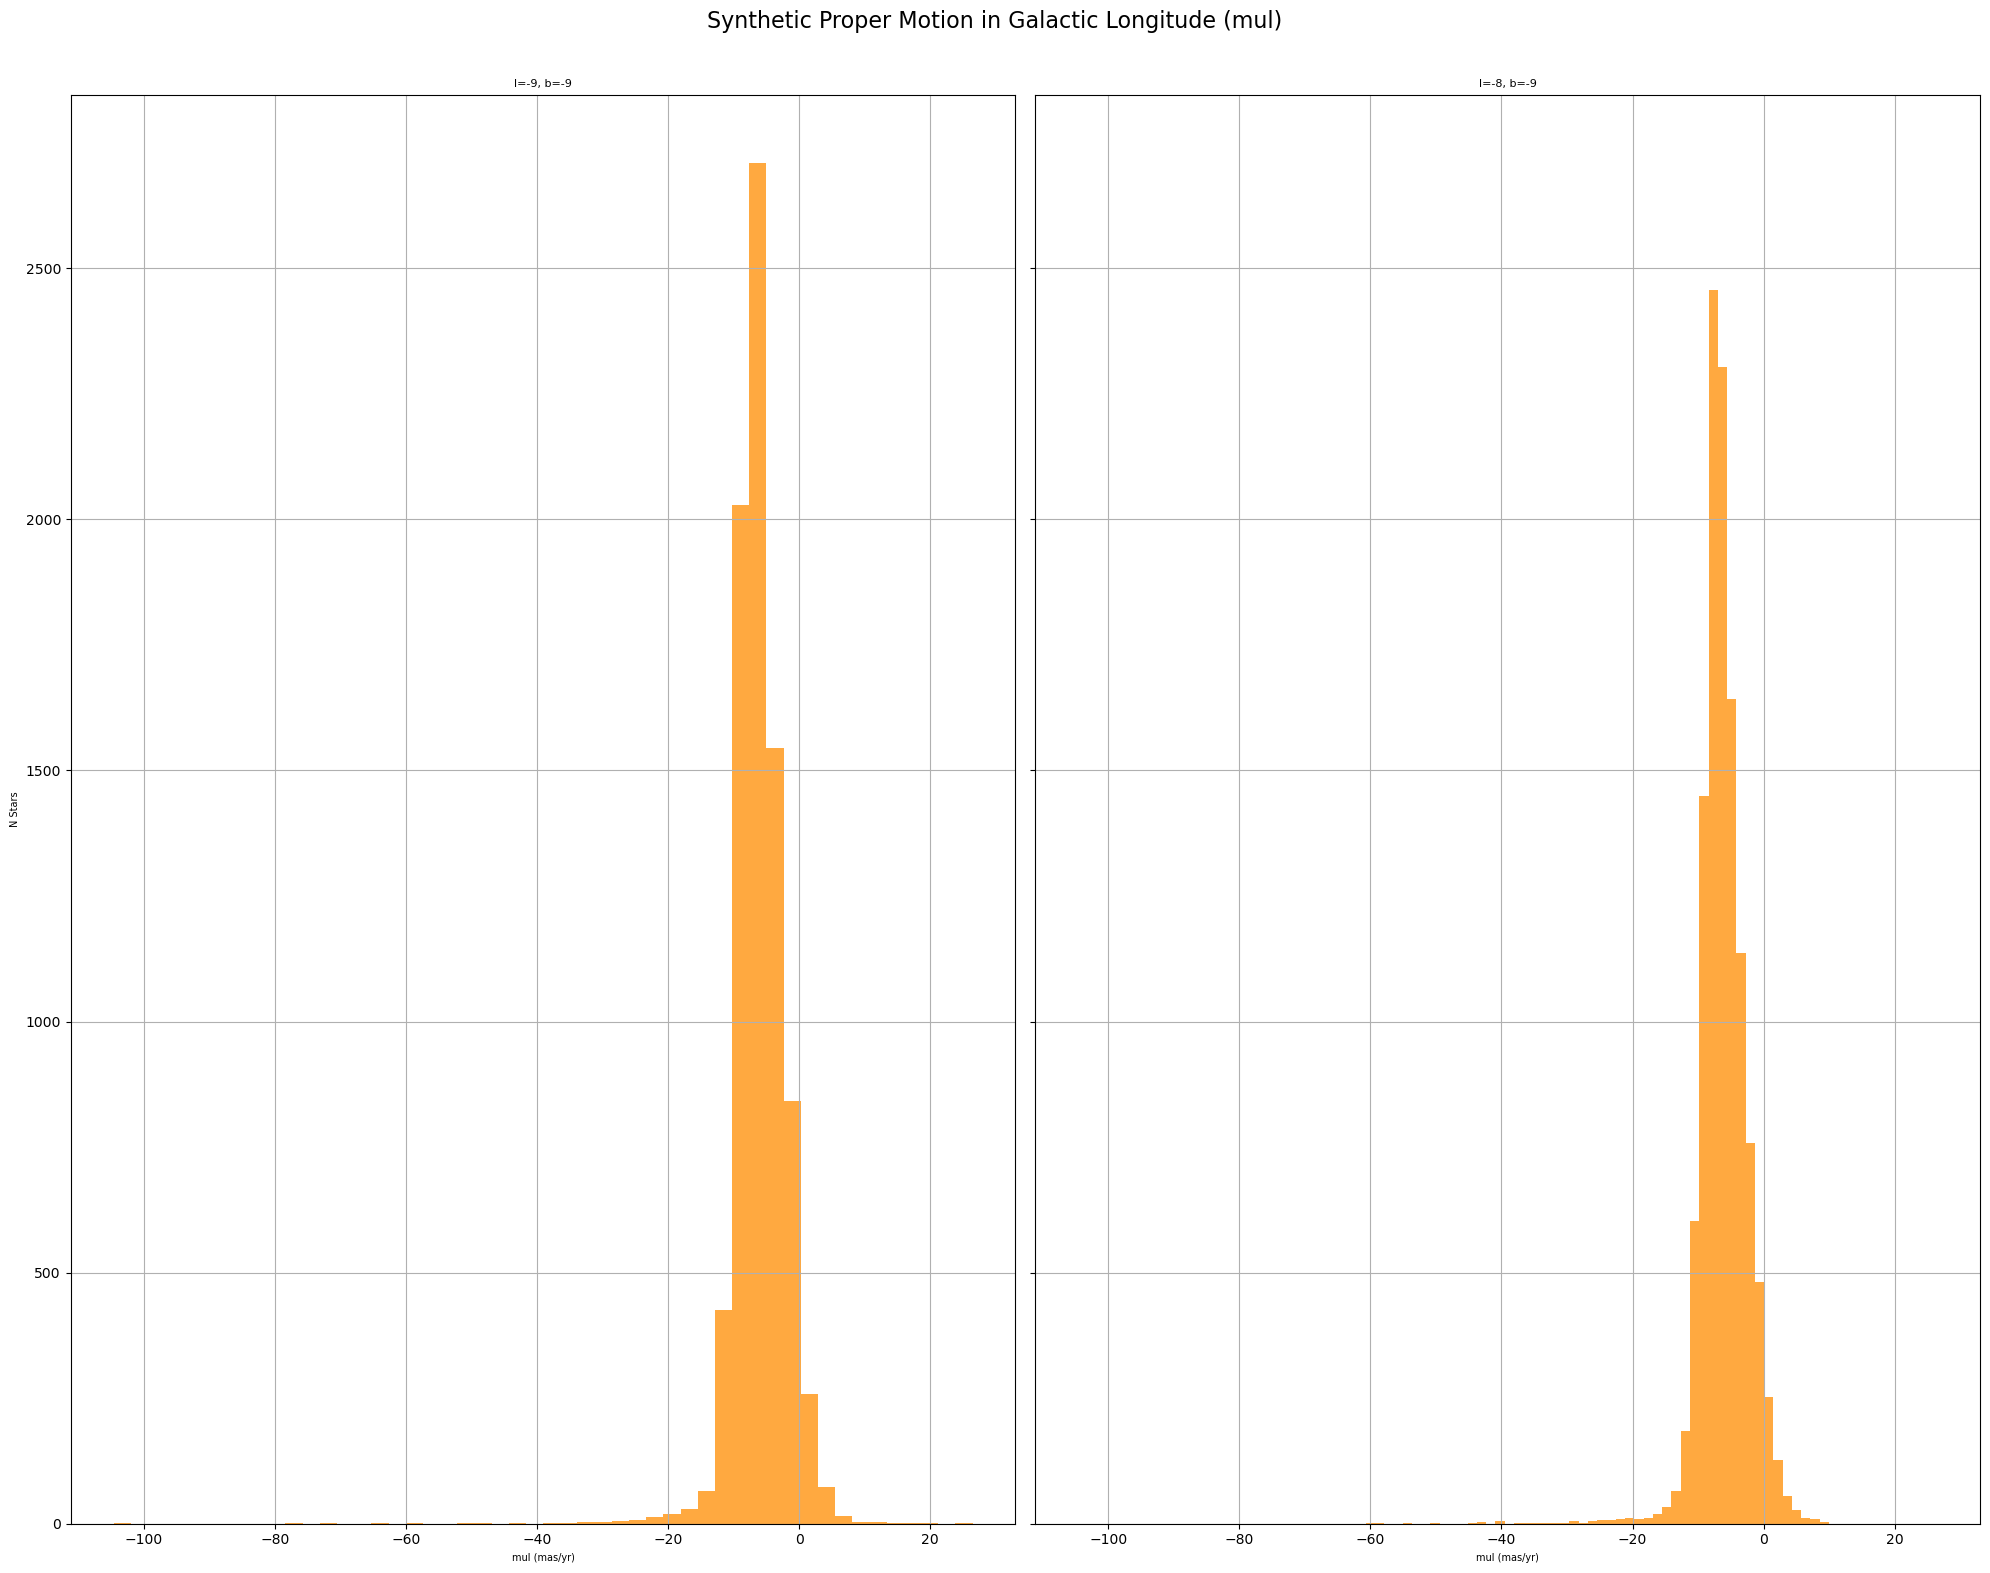

In [14]:

# Initialize the synthetic population model
synthdata.init_populations()

# Set the grid ranges
l_vals = np.arange(-9, -7, 1)
b_vals = np.arange(-9, -8, 1)

# Set up the plot
fig, axes = plt.subplots(len(b_vals), len(l_vals), figsize=(20, 16), sharex=True, sharey=True, squeeze=False)
fig.suptitle("Synthetic Proper Motion in Galactic Longitude (mul)", fontsize=16)

# Loop over each (l, b) coordinate and plot the histogram
for i, b in enumerate(b_vals):
    for j, l in enumerate(l_vals):
        try:
            cat2, distr2 = synthdata.process_location(
                l_deg=l, b_deg=b, solid_angle=0.01*np.pi, solid_angle_unit='deg^2'
            )
            mul_vals = cat2['mul'].astype(float).values

            ax = axes[i, j]
            ax.hist(mul_vals, bins=50, color='darkorange', alpha=0.75)
            ax.set_title(f"l={l}, b={b}", fontsize=8)
            ax.grid(True)

            if i == len(b_vals) - 1:
                ax.set_xlabel('mul (mas/yr)', fontsize=7)
            if j == 0:
                ax.set_ylabel('N Stars', fontsize=7)

        except Exception as e:
            ax = axes[i, j]
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
            ax.set_title(f"l={l}, b={b}", fontsize=8)
            ax.grid(True)

# Layout and show
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()




############################# update location #############################
 1819983 - # set location to: 
 1819985 - l, b = (-9.00 deg, -9.00 deg)
 1820015 - # set solid_angle to:
 1820019 - solid_angle = 3.142e-02 deg^2


INFO: Query finished. [astroquery.utils.tap.core]




############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 1822871 - # From density profile (number density)
 1822875 - expected_total_iMass = 146260.9193
 1822878 - expected_total_eMass = 80171.2468
 1822881 - average_iMass_per_star = 0.5739
 1822884 - mass_loss_correction = 0.5481
 1822887 - n_expected_stars = 254869.4839
 1822893 - # Determine velocities when position are generated 


  0%|          | 0/254308 [00:00<?, ?it/s]

 1827521 - # From Generated Field:
 1827525 - generated_stars = 4892
 1827528 - generated_total_iMass = 4692.4510
 1827604 - generated_total_eMass = 4685.0653
 1827608 - det_mass_loss_corr = 0.9984
 1827672 - # Done


# Population 1;  halo -----------------------------------------------------
 1828277 - # From density profile (number density)
 1828281 - expected_total_iMass = 1742.2185
 1828285 - expected_total_eMass = 917.1499
 1828288 - average_iMass_per_star = 0.5739
 1828291 - mass_loss_correction = 0.5264
 1828295 - n_expected_stars = 3035.9329
 1828301 - # Determine velocities when position are generated 
 1828465 - # From Generated Field:
 1828469 - generated_stars = 46
 1828472 - generated_total_iMass = 32.7379
 1828483 - generated_total_eMass = 32.7213
 1828487 - det_mass_loss_corr = 0.9995
 1828552 - # Done


# Population 2;  nsd ------------------------------------------------------
 1830027 - # From density profile (number density)
 1830032 - expected_total_iMass = 0.0000
 

INFO: Query finished. [astroquery.utils.tap.core]




############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 1875344 - # From density profile (number density)
 1875347 - expected_total_iMass = 171453.5801
 1875351 - expected_total_eMass = 93980.3152
 1875354 - average_iMass_per_star = 0.5739
 1875357 - mass_loss_correction = 0.5481
 1875360 - n_expected_stars = 298769.3889
 1875365 - # Determine velocities when position are generated 


  0%|          | 0/298760 [00:00<?, ?it/s]

 1880830 - # From Generated Field:
 1880833 - generated_stars = 8153
 1880836 - generated_total_iMass = 7642.9508
 1880847 - generated_total_eMass = 7633.3535
 1880851 - det_mass_loss_corr = 0.9987
 1880914 - # Done


# Population 1;  halo -----------------------------------------------------
 1881552 - # From density profile (number density)
 1881557 - expected_total_iMass = 1839.2535
 1881560 - expected_total_eMass = 968.2317
 1881563 - average_iMass_per_star = 0.5739
 1881567 - mass_loss_correction = 0.5264
 1881570 - n_expected_stars = 3205.0229
 1881577 - # Determine velocities when position are generated 
 1881743 - # From Generated Field:
 1881747 - generated_stars = 66
 1881751 - generated_total_iMass = 47.1499
 1881762 - generated_total_eMass = 47.0483
 1881766 - det_mass_loss_corr = 0.9978
 1881832 - # Done


# Population 2;  nsd ------------------------------------------------------
 1883699 - # From density profile (number density)
 1883704 - expected_total_iMass = 0.0000
 

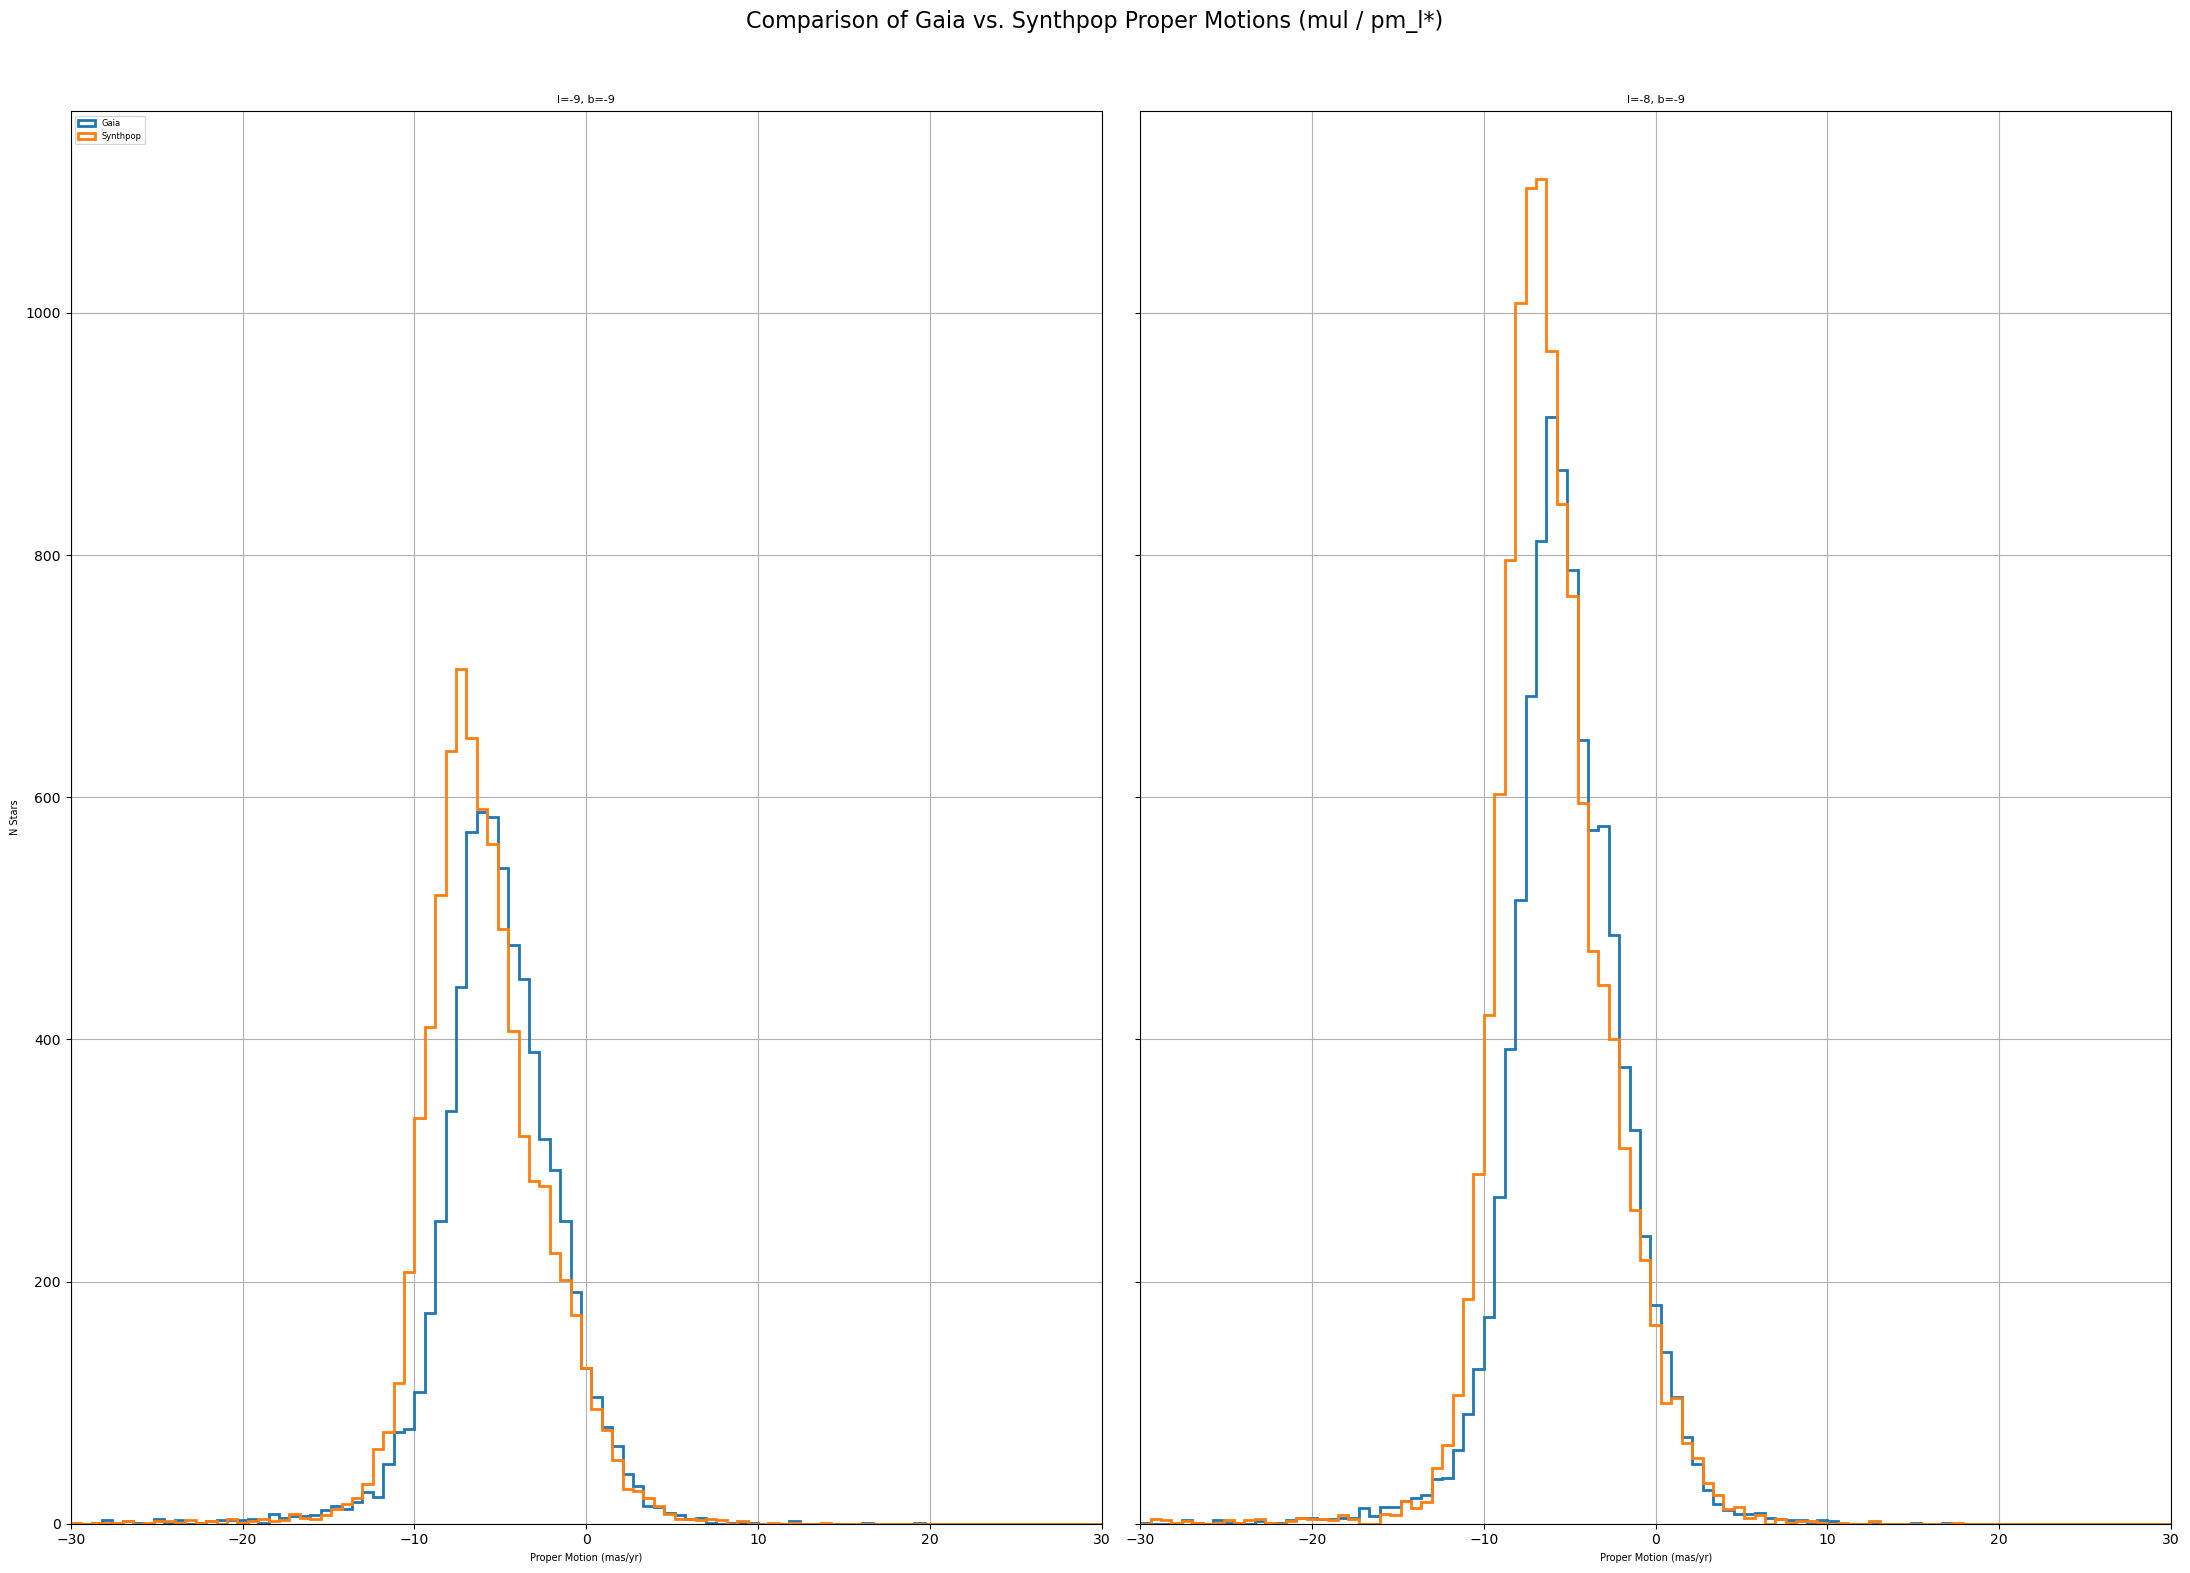

In [16]:
# Initialize synthetic population
synthdata.init_populations()

# Define coordinate grid
l_vals = np.arange(-9, -7, 1)
b_vals = np.arange(-9, -8, 1)

# Plot style
bin_edges = np.linspace(-30, 30, 100)

fig, axes = plt.subplots(len(b_vals), len(l_vals), figsize=(22, 16), sharex=True, sharey=True, squeeze=False)
fig.suptitle("Comparison of Gaia vs. Synthpop Proper Motions (mul / pm_l*)", fontsize=16)

Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"
Gaia.ROW_LIMIT = -1

for i, b in enumerate(b_vals):
    for j, l in enumerate(l_vals):
        ax = axes[i, j]
        try:
            # --- GAIA ---
            center = SkyCoord(l=l*u.deg, b=b*u.deg, frame='galactic').icrs
            radius = 0.1 * u.deg

            job = Gaia.cone_search_async(center, radius)
            result = job.get_results()

            mask = (result['phot_g_mean_mag'] < 20)
            filtered = result[mask]

            ra_vals = np.array(filtered['ra'], dtype=float)
            dec_vals = np.array(filtered['dec'], dtype=float)
            pmra_vals = np.array(filtered['pmra'], dtype=float)
            pmdec_vals = np.array(filtered['pmdec'], dtype=float)

            coords = SkyCoord(ra=ra_vals*u.deg,
                              dec=dec_vals*u.deg,
                              pm_ra_cosdec=pmra_vals*u.mas/u.yr,
                              pm_dec=pmdec_vals*u.mas/u.yr,
                              frame='icrs')

            gal_coords = coords.transform_to('galactic')
            pm_l_cosb = gal_coords.pm_l_cosb.to(u.mas/u.yr).value

            # --- SYNTHPOP ---
            cat2, distr2 = synthdata.process_location(
                l_deg=l, b_deg=b, solid_angle=0.01*np.pi, solid_angle_unit='deg^2'
            )
            mul_vals = cat2['mul'].astype(float).values

            # --- PLOT ---
            ax.hist(pm_l_cosb, bins=bin_edges, histtype='step', color='#1f77b4', linewidth=2, label='Gaia')
            ax.hist(mul_vals, bins=bin_edges, histtype='step', color='#ff7f0e', linewidth=2, label='Synthpop')
            ax.set_title(f"l={l}, b={b}", fontsize=8)
            ax.grid(True)

            if i == len(b_vals) - 1:
                ax.set_xlabel('Proper Motion (mas/yr)', fontsize=7)
            if j == 0:
                ax.set_ylabel('N Stars', fontsize=7)

            if i == 0 and j == 0:
                ax.legend(loc='upper left', frameon=True, fontsize=6)

            ax.set_xlim(-30, 30)

        except Exception as e:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
            ax.set_title(f"l={l}, b={b}", fontsize=8)
            ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [19]:
import pandas as pd

# ... (previous imports and initialization code here)

# Collect stats for output
stats_list = []

for i, b in enumerate(b_vals):
    for j, l in enumerate(l_vals):
        stats_entry = {'l': l, 'b': b}
        try:
            # --- GAIA ---
            center = SkyCoord(l=l*u.deg, b=b*u.deg, frame='galactic').icrs
            radius = 0.1 * u.deg

            job = Gaia.cone_search_async(center, radius)
            result = job.get_results()

            mask = (result['phot_g_mean_mag'] < 20)
            filtered = result[mask]
            valid_pm = (~np.isnan(filtered['pmra'])) & (~np.isnan(filtered['pmdec']))
            filtered = filtered[valid_pm]

            ra_vals = np.array(filtered['ra'], dtype=float)
            dec_vals = np.array(filtered['dec'], dtype=float)
            pmra_vals = np.array(filtered['pmra'], dtype=float)
            pmdec_vals = np.array(filtered['pmdec'], dtype=float)

            coords = SkyCoord(ra=ra_vals*u.deg,
                              dec=dec_vals*u.deg,
                              pm_ra_cosdec=pmra_vals*u.mas/u.yr,
                              pm_dec=pmdec_vals*u.mas/u.yr,
                              frame='icrs')

            gal_coords = coords.transform_to('galactic')
            pm_l_cosb = gal_coords.pm_l_cosb.to(u.mas/u.yr).value

            # Save Gaia stats
            if len(pm_l_cosb) > 0:
                stats_entry['gaia_median'] = np.median(pm_l_cosb)
                stats_entry['gaia_std'] = np.std(pm_l_cosb)
            else:
                stats_entry['gaia_median'] = np.nan
                stats_entry['gaia_std'] = np.nan

            # --- SYNTHPOP ---
            cat2, distr2 = synthdata.process_location(
                l_deg=l, b_deg=b, solid_angle=0.01*np.pi, solid_angle_unit='deg^2'
            )
            mul_vals = cat2['mul'].astype(float).values

            if len(mul_vals) > 0:
                stats_entry['synth_median'] = np.median(mul_vals)
                stats_entry['synth_std'] = np.std(mul_vals)
            else:
                stats_entry['synth_median'] = np.nan
                stats_entry['synth_std'] = np.nan

        except Exception as e:
            stats_entry['gaia_median'] = np.nan
            stats_entry['gaia_std'] = np.nan
            stats_entry['synth_median'] = np.nan
            stats_entry['synth_std'] = np.nan

        stats_list.append(stats_entry)

# Create table
stats_df = pd.DataFrame(stats_list)
stats_df = stats_df.sort_values(by=['b', 'l']).reset_index(drop=True)

# Show top of the table
print(stats_df.head())

# Optionally: save to CSV
#stats_df.to_csv("gaia_vs_synthpop_stats.csv", index=False)




############################# update location #############################
 2463002 - # set location to: 
 2463005 - l, b = (-9.00 deg, -9.00 deg)
 2463035 - # set solid_angle to:
 2463038 - solid_angle = 3.142e-02 deg^2


INFO: Query finished. [astroquery.utils.tap.core]




############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 2465953 - # From density profile (number density)
 2465957 - expected_total_iMass = 146264.9570
 2465961 - expected_total_eMass = 80173.4600
 2465964 - average_iMass_per_star = 0.5739
 2465968 - mass_loss_correction = 0.5481
 2465971 - n_expected_stars = 254876.5198
 2465977 - # Determine velocities when position are generated 


  0%|          | 0/255583 [00:00<?, ?it/s]

 2470841 - # From Generated Field:
 2470845 - generated_stars = 5085
 2470848 - generated_total_iMass = 4867.5812
 2470862 - generated_total_eMass = 4859.5135
 2470866 - det_mass_loss_corr = 0.9983
 2470937 - # Done


# Population 1;  halo -----------------------------------------------------
 2471589 - # From density profile (number density)
 2471593 - expected_total_iMass = 1742.1729
 2471596 - expected_total_eMass = 917.1259
 2471599 - average_iMass_per_star = 0.5739
 2471603 - mass_loss_correction = 0.5264
 2471606 - n_expected_stars = 3035.8534
 2471613 - # Determine velocities when position are generated 
 2471783 - # From Generated Field:
 2471787 - generated_stars = 25
 2471791 - generated_total_iMass = 17.5700
 2471801 - generated_total_eMass = 17.4979
 2471804 - det_mass_loss_corr = 0.9959
 2471868 - # Done


# Population 2;  nsd ------------------------------------------------------
 2473370 - # From density profile (number density)
 2473374 - expected_total_iMass = 0.0000
 

INFO: Query finished. [astroquery.utils.tap.core]




############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 2517441 - # From density profile (number density)
 2517446 - expected_total_iMass = 171455.1123
 2517449 - expected_total_eMass = 93981.1550
 2517453 - average_iMass_per_star = 0.5739
 2517456 - mass_loss_correction = 0.5481
 2517460 - n_expected_stars = 298772.0589
 2517466 - # Determine velocities when position are generated 


  0%|          | 0/298818 [00:00<?, ?it/s]

 2522737 - # From Generated Field:
 2522741 - generated_stars = 7950
 2522744 - generated_total_iMass = 7451.9947
 2522755 - generated_total_eMass = 7442.8346
 2522759 - det_mass_loss_corr = 0.9988
 2522827 - # Done


# Population 1;  halo -----------------------------------------------------
 2523430 - # From density profile (number density)
 2523434 - expected_total_iMass = 1839.2638
 2523438 - expected_total_eMass = 968.2371
 2523441 - average_iMass_per_star = 0.5739
 2523445 - mass_loss_correction = 0.5264
 2523448 - n_expected_stars = 3205.0409
 2523455 - # Determine velocities when position are generated 
 2523608 - # From Generated Field:
 2523612 - generated_stars = 65
 2523615 - generated_total_iMass = 46.2670
 2523626 - generated_total_eMass = 46.1661
 2523630 - det_mass_loss_corr = 0.9978
 2523693 - # Done


# Population 2;  nsd ------------------------------------------------------
 2525200 - # From density profile (number density)
 2525204 - expected_total_iMass = 0.0000
 

   l  b  gaia_median  gaia_std  synth_median  synth_std
0 -9 -9    -5.160074  4.055224     -6.327670   5.649083
1 -8 -9    -5.328912  3.540990     -6.334141   4.054606


In [18]:
print(filtered[['ra', 'dec', 'pmra', 'pmdec', 'phot_g_mean_mag']][:5])


        ra                 dec                 pmra                pmdec        phot_g_mean_mag
       deg                 deg               mas / yr             mas / yr            mag      
------------------ ------------------- -------------------- ------------------- ---------------
271.06327001705023  -40.33305058979772 -0.34221205043353337 -2.2252698131526247       18.622387
 271.0624285061675  -40.33449210297093                   --                  --       19.296947
  271.062147602609  -40.33444276940917    4.615432832781339  -5.849214934048103       19.013308
271.06388091768775  -40.33317704939014  -0.7128292323766273  -4.635182834158328       19.894003
 271.0622329142314 -40.332938275896794   3.9122664909323555  -4.941203405373654       16.980507
